# 1. Imports

In [1]:
import sys
sys.path.append("../")

In [2]:
# Project imports
from src.data_utils import load_device_signals, create_windows

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data science libraries
import numpy as np
import pandas as pd

# 2. Baseline and cognitive load signals

In [3]:
participant_id = 3

In [4]:
signals_b = load_device_signals(participant_id = participant_id, condition = 'baseline')
s_t = signals_b["bvp"]

In [5]:
print(s_t.shape)

(5300,)


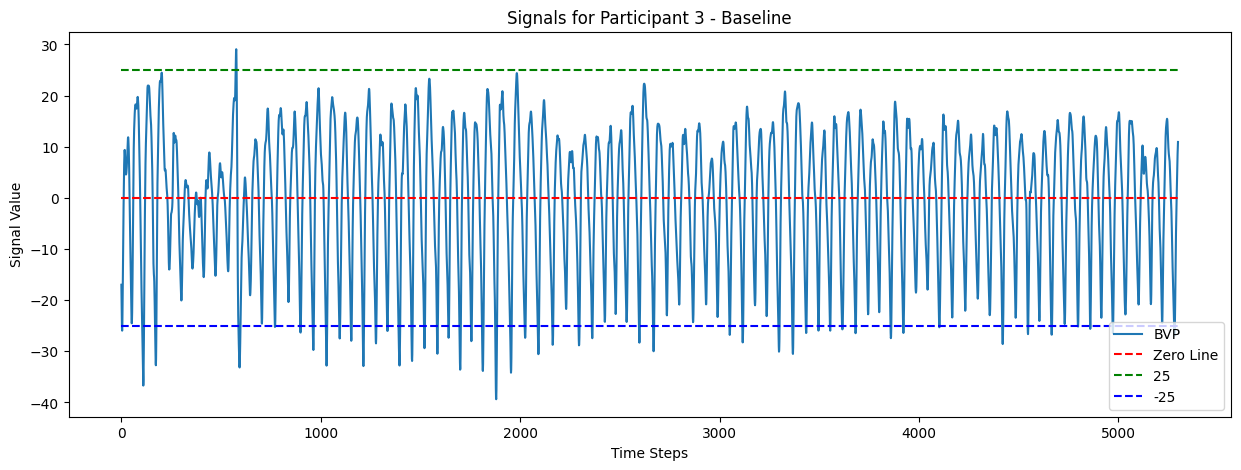

In [6]:
plt.figure(figsize=(15, 5))
plt.plot(s_t, label='BVP')
plt.hlines(0, xmin=0, xmax=s_t.shape[0], colors='r', linestyles='--', label='Zero Line')
plt.hlines(25, xmin=0, xmax=s_t.shape[0], colors='g', linestyles='--', label='25')
plt.hlines(-25, xmin=0, xmax=s_t.shape[0], colors='b', linestyles='--', label='-25')
plt.legend()
plt.title('Signals for Participant 3 - Baseline')
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.show()

In [7]:
signals_b_c = load_device_signals(participant_id = participant_id, condition = 'cognitive_load')
s_t_c = signals_b_c["bvp"]

In [8]:
print(s_t_c.shape)

(7618,)


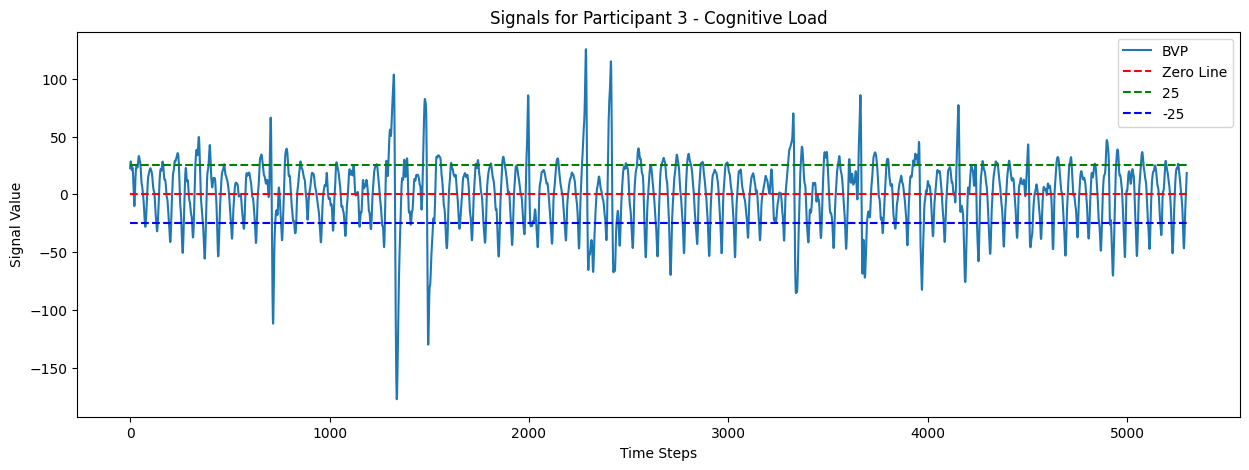

In [9]:
uniform_length = min(s_t.shape[0], s_t_c.shape[0])
s_t_c_uniform = s_t_c[:uniform_length]

plt.figure(figsize=(15, 5))
plt.plot(s_t_c_uniform, label='BVP')
plt.hlines(0, xmin=0, xmax=s_t_c_uniform.shape[0], colors='r', linestyles='--', label='Zero Line')
plt.hlines(25, xmin=0, xmax=s_t_c_uniform.shape[0], colors='g', linestyles='--', label='25')
plt.hlines(-25, xmin=0, xmax=s_t_c_uniform.shape[0], colors='b', linestyles='--', label='-25')
plt.legend()
plt.title('Signals for Participant 3 - Cognitive Load')
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.show()

# 2. Feature extraction

Let us define a few features that we can extract from the signal windows. We engineered these features based on our observations of the data.

In [10]:
from scipy.signal import find_peaks, peak_widths, peak_prominences

def max_amp(window):
    return (window.max() - window.min()) / 2

def sign_changes(window):
    derivative = np.diff(window)
    return np.sum(np.diff(np.sign(derivative)) != 0)

def mean_peak_width(signal):
    peaks, _ = find_peaks(signal, prominence=1)  # Adjust prominence as needed
    if len(peaks) == 0:
        return 0
    widths, _, _, _ = peak_widths(signal, peaks, rel_height=0.5)
    return np.mean(widths)

def mean_peak_prominence(signal):
    peaks, _ = find_peaks(signal, prominence=1)  # Adjust prominence as needed
    if len(peaks) == 0:
        return 0
    prominences = peak_prominences(signal, peaks)[0]
    return np.mean(prominences)

def post_peak_area(signal, time_window=50):
    peaks, _ = find_peaks(signal)
    if len(peaks) == 0:
        return 0
    main_peak_idx = peaks[np.argmax(signal[peaks])]
    right_end = min(len(signal), main_peak_idx + time_window)
    return np.sum(np.abs(signal[main_peak_idx:right_end]))

def pre_peak_area(signal, time_window=50):
    peaks, _ = find_peaks(signal)
    if len(peaks) == 0:
        return 0
    main_peak_idx = peaks[np.argmax(signal[peaks])]
    left_start = max(0, main_peak_idx - time_window)
    return np.sum(np.abs(signal[left_start:main_peak_idx]))

def create_features(window):
    return {
        'max_amp': max_amp(window),
        'sign_changes': sign_changes(window),
        'mean_peak_width': mean_peak_width(window),
        'mean_peak_prominence': mean_peak_prominence(window),
        'post_peak_area': post_peak_area(window),
        'pre_peak_area': pre_peak_area(window)
    }

Set window size and step size for creating windows.

In [11]:
window_size = 256
step_size = 128

Let's visualize a few windows from the baseline BVP signal, along with their features.

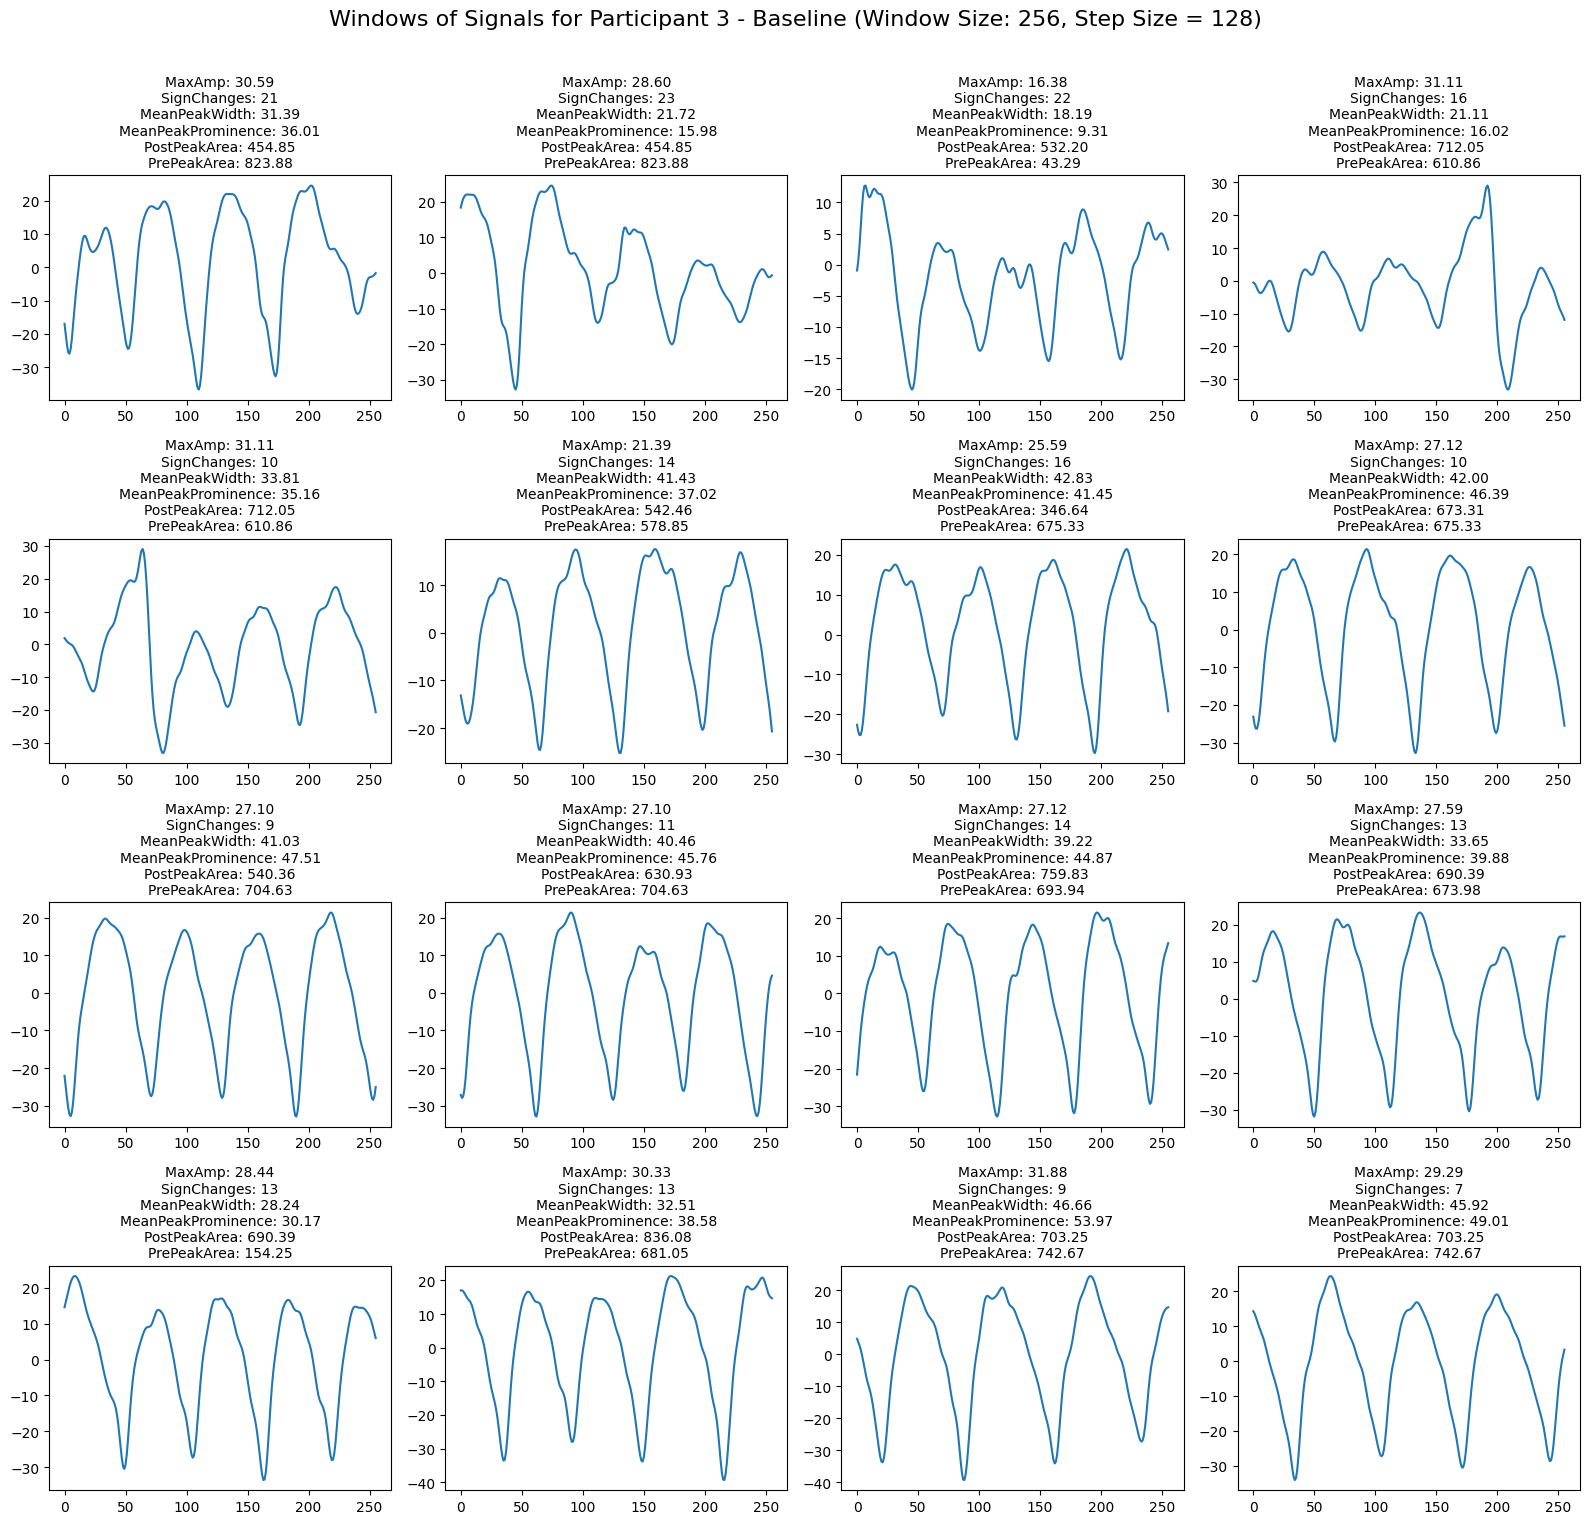

In [12]:
s_t_windows = create_windows(s_t, window_size=window_size, step_size=step_size)

fig, ax = plt.subplots(4, 4, figsize=(16, 16))
ax = ax.flatten()
for i in range(16):
    ax[i].plot(s_t_windows[i])
    features = create_features(s_t_windows[i])
    ax[i].set_title(f'MaxAmp: {features["max_amp"]:.2f}\nSignChanges: {features["sign_changes"]}\nMeanPeakWidth: {features["mean_peak_width"]:.2f}\nMeanPeakProminence: {features["mean_peak_prominence"]:.2f}\nPostPeakArea: {features["post_peak_area"]:.2f}\nPrePeakArea: {features["pre_peak_area"]:.2f}', fontsize=10)
fig.suptitle(f'Windows of Signals for Participant 3 - Baseline (Window Size: {window_size}, Step Size = {step_size})', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

Now, a few windows from the cognitive load BVP signal, along with their features.

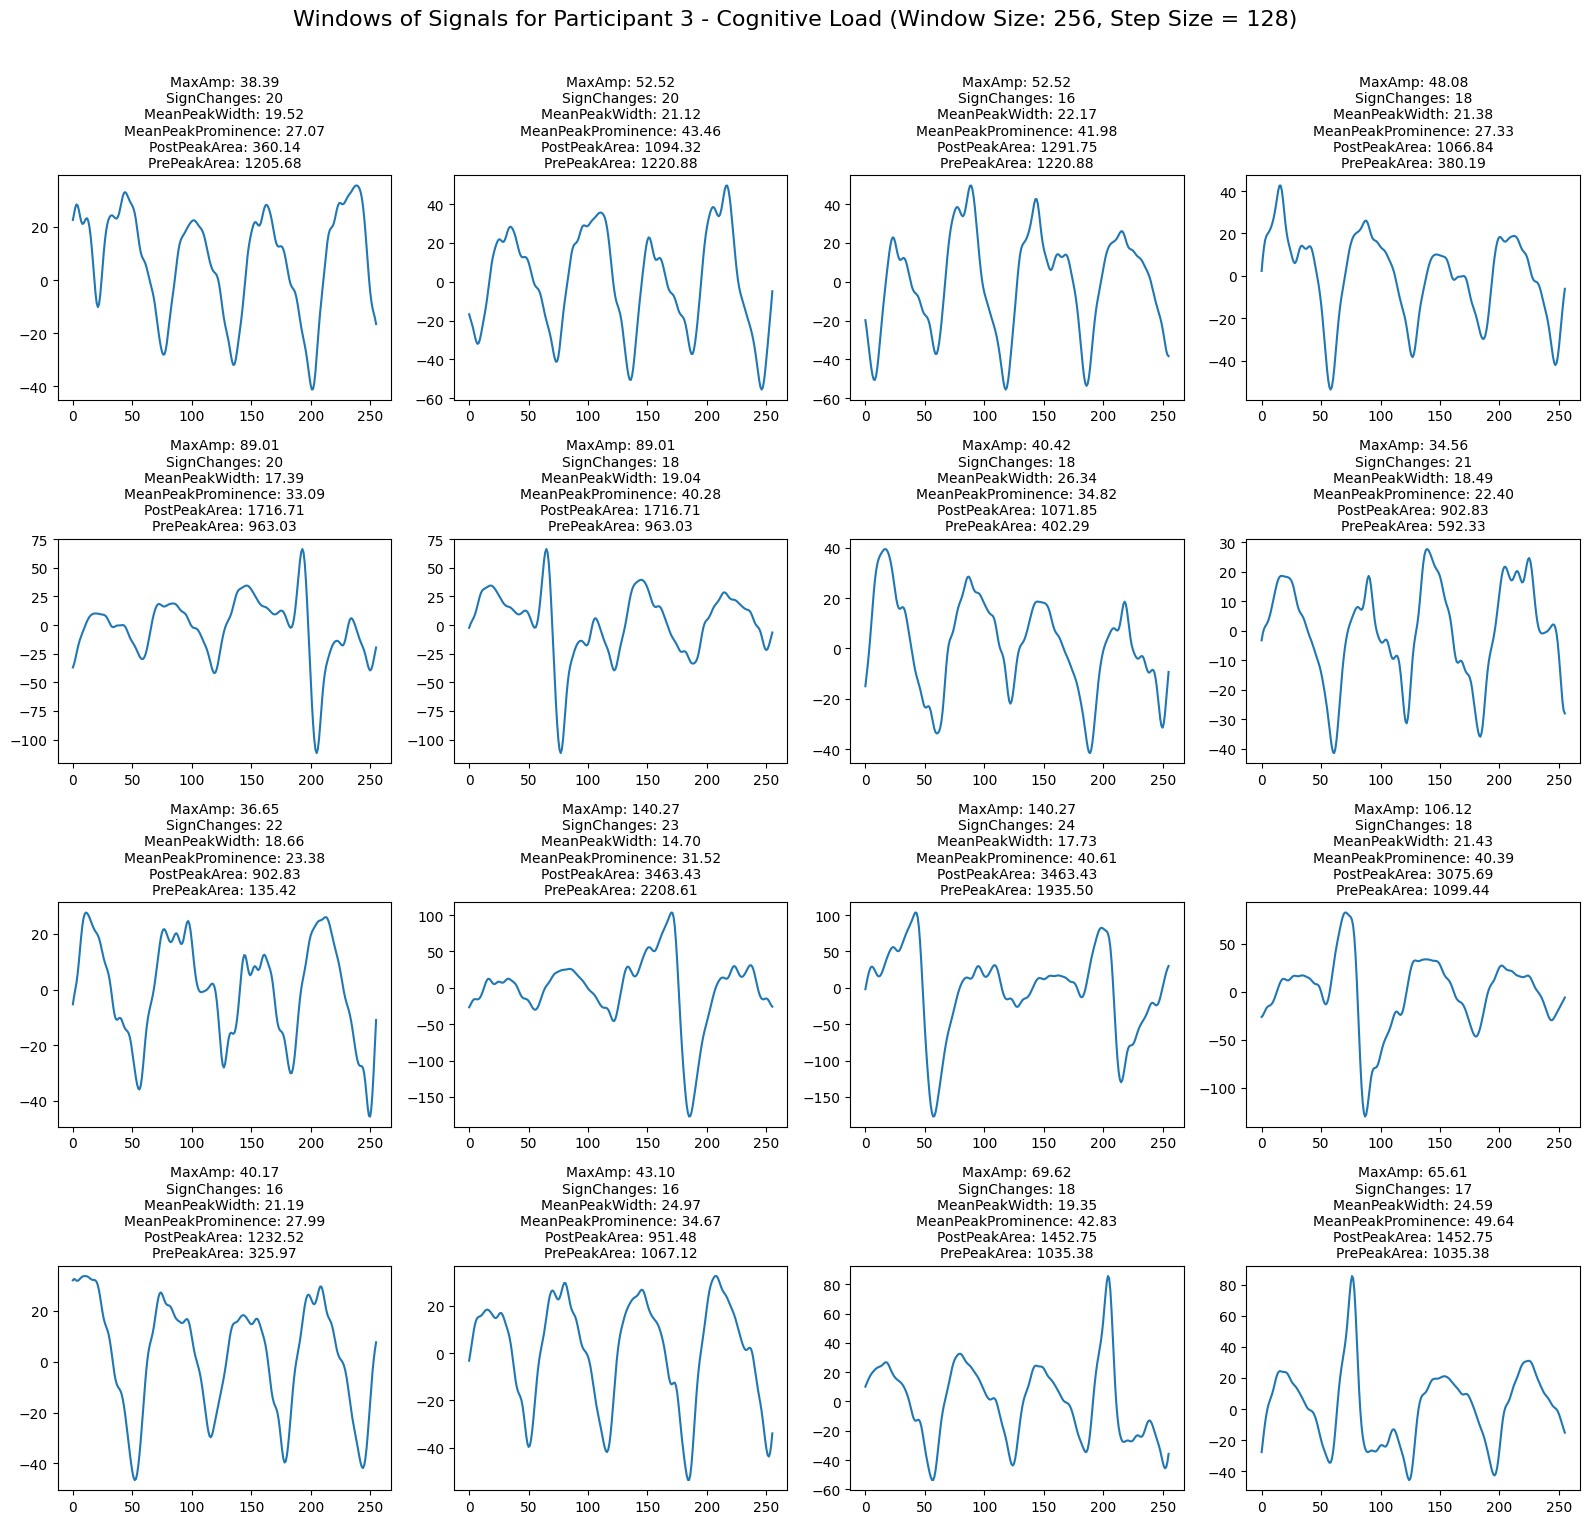

In [13]:
s_t_c_windows = create_windows(s_t_c, window_size=window_size, step_size=step_size)

fig, ax = plt.subplots(4, 4, figsize=(16, 16))
ax = ax.flatten()
for i in range(16):
    ax[i].plot(s_t_c_windows[i], label=f'Window {i+1}')
    features = create_features(s_t_c_windows[i])
    ax[i].set_title(f'MaxAmp: {features["max_amp"]:.2f}\nSignChanges: {features["sign_changes"]}\nMeanPeakWidth: {features["mean_peak_width"]:.2f}\nMeanPeakProminence: {features["mean_peak_prominence"]:.2f}\nPostPeakArea: {features["post_peak_area"]:.2f}\nPrePeakArea: {features["pre_peak_area"]:.2f}', fontsize=10)
fig.suptitle(f'Windows of Signals for Participant 3 - Cognitive Load (Window Size: {window_size}, Step Size = {step_size})', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

A quick comparison of the features between the baseline and cognitive load signals using Yuen-Welch's test.

In [14]:
from scipy.stats import ttest_ind
feature_names = ["max_amp", "sign_changes", "mean_peak_width", "mean_peak_prominence", "post_peak_area", "pre_peak_area"]
features_b = np.array([create_features(window) for window in s_t_windows])
features_c = np.array([create_features(window) for window in s_t_c_windows])
for feature_name in feature_names:
    features_b_particular_feature = [window_features[feature_name] for window_features in features_b]
    features_c_particular_feature = [window_features[feature_name] for window_features in features_c]
    t_stat, p_value = ttest_ind(features_b_particular_feature, features_c_particular_feature, equal_var=False, trim=0.1)
    print(f"{feature_name}: t-statistic = {t_stat}, p-value = {p_value}")

max_amp: t-statistic = -11.357445757106246, p-value = 8.866670394534608e-16
sign_changes: t-statistic = -5.6301480346672115, p-value = 2.727181386041997e-07
mean_peak_width: t-statistic = 7.721670032300314, p-value = 4.072257003159671e-11
mean_peak_prominence: t-statistic = -4.141997249999634, p-value = 8.946712308205623e-05
post_peak_area: t-statistic = -7.418850648240968, p-value = 1.045557210579606e-09
pre_peak_area: t-statistic = -7.291852597408899, p-value = 9.70699841521809e-10


Now, we prepare the combined features and labels for training a machine learning model.

In [15]:
# Features: already computed
X_b = np.array([list(window_feat.values()) for window_feat in features_b])  # Baseline
X_c = np.array([list(window_feat.values()) for window_feat in features_c])  # Cognitive load

# Labels
y_b = np.zeros(len(X_b))  # Baseline = 0
y_c = np.ones(len(X_c))   # Cognitive Load = 1

# Combine
X = np.vstack([X_b, X_c]) 
y = np.concatenate([y_b, y_c])

feature_names = list(features_b[0].keys())  # Ensure consistent order


# 3. Feature selection via MDI in Random Forest

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.97      0.98        32
         1.0       0.98      1.00      0.99        47

    accuracy                           0.99        79
   macro avg       0.99      0.98      0.99        79
weighted avg       0.99      0.99      0.99        79

Confusion Matrix:


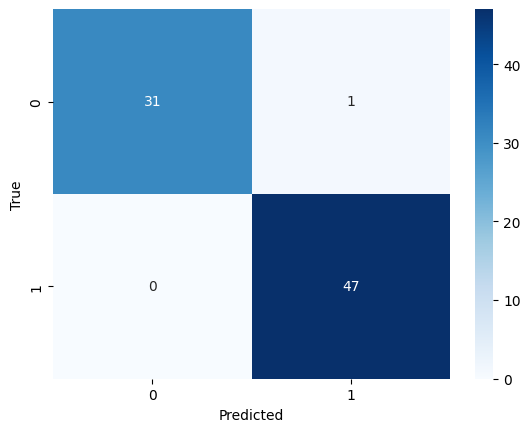

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, stratify=y, random_state=42)

# Train
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


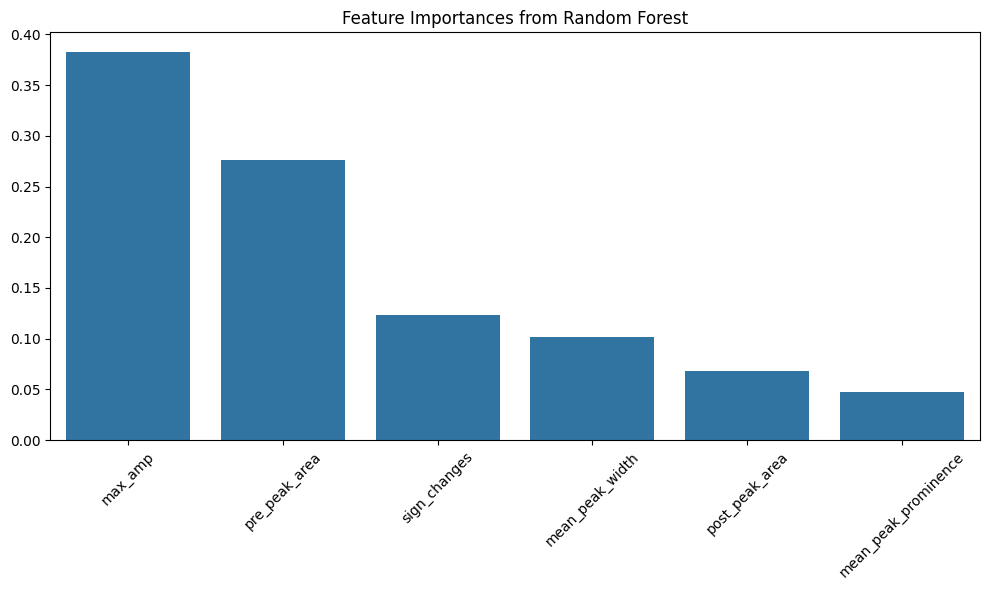

In [17]:
import pandas as pd

importances = clf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=[feature_names[i] for i in sorted_idx], y=importances[sorted_idx])
plt.xticks(rotation=45)
plt.title("Feature Importances from Random Forest")
plt.tight_layout()
plt.show()


In [18]:
import pandas as pd
import numpy as np

df = pd.DataFrame(X, columns=feature_names)
selected_features = [feature_names[i] for i in sorted_idx[:3]]

df = df[selected_features].round(2)
df["label"] = y

df.to_csv("../output/features_for_sirus.csv", index=False)

# 4. Rule-based classification using SIRUS

Now, we put the file features_for_sirus.csv into an R script to run SIRUS. The R script is as follows:

```R
require(sirus)
library(dplyr)

features_for_sirus <- read.csv("features_for_sirus.csv")
data <- features_for_sirus %>% select(1:3)  # First 3 columns as features
data <- as.data.frame(data)
y <- features_for_sirus$label

sirus.m <- sirus.fit(data, y)
rules <- capture.output(sirus.print(sirus.m))
y_pred <- ifelse(sirus.predict(sirus.m, data) < 0.5, 0, 1)
```

It generates the following rules:

```
[' [1] "Proportion of class 1 = 0.602 - Sample size n = 88"                            ',
 ' [2] "if max_amp < 31.9 then 0.0294 (n=34) else 0.963 (n=54)"                        ',
 ' [3] "if pre_peak_area < 842 then 0.34 (n=53) else 1 (n=35)"                         ',
 ' [4] "if post_peak_area < 843 then 0.205 (n=44) else 1 (n=44)"                       ',
 ' [5] "if post_peak_area < 701 then 0.114 (n=35) else 0.925 (n=53)"                   ',
 ' [6] "if max_amp >= 31.9 & post_peak_area < 843 then 0.818 (n=11) else 0.571 (n=77)" ',
 ' [7] "if post_peak_area < 843 & pre_peak_area < 842 then 0.0789 (n=38) else 1 (n=50)"',
 ' [8] "if max_amp >= 31.9 & pre_peak_area < 842 then 0.895 (n=19) else 0.522 (n=69)"  ',
 ' [9] "if pre_peak_area < 685 then 0.295 (n=44) else 0.909 (n=44)"                    ',
 '[10] "if max_amp >= 31.9 & max_amp < 42.6 then 0.8 (n=10) else 0.577 (n=78)"         ',
 '[11] "if max_amp < 31.9 & pre_peak_area < 557 then 0 (n=17) else 0.746 (n=71)"       ']
```

From the output of SIRUS, we can extract one rule that performs comparatively well, instead of taking all the rules together. However, note that this manual rule pruning might not be stable. SIRUS is proven to be stable.

In [19]:
def rule(window_features):
    return int(window_features['max_amp'] >= 31.9)

In [20]:
df["rule_label"] = df.apply(rule, axis=1)

In [21]:
df

,max_amp,pre_peak_area,sign_changes,label,rule_label
0,30.59,823.88,21.0,0.0,0
1,28.60,823.88,23.0,0.0,0
2,16.38,43.29,22.0,0.0,0
3,31.11,610.86,16.0,0.0,0
4,31.11,610.86,10.0,0.0,0
...,...,...,...,...,...
93,47.96,1017.12,13.0,1.0,1
94,43.29,1021.75,13.0,1.0,1
95,45.32,1113.27,11.0,1.0,1
96,47.44,1113.27,10.0,1.0,1


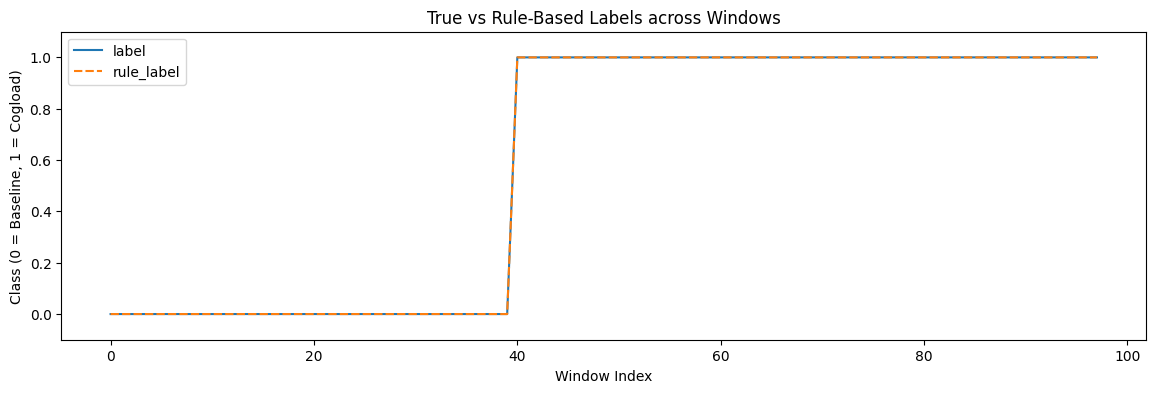

In [22]:
plt.figure(figsize=(14, 4))
sns.lineplot(data=df[['label', 'rule_label']])
plt.xlabel("Window Index")
plt.ylabel("Class (0 = Baseline, 1 = Cogload)")
plt.title("True vs Rule-Based Labels across Windows")
plt.legend()
plt.ylim(-0.1, 1.1)
plt.show()

In [23]:
accuracy = np.mean(df['label'] == df['rule_label'])
print(f"Rule-based accuracy: {accuracy:.2f}")

Rule-based accuracy: 1.00
